# 🏨 Hotel Booking Analysis

**Goal:** Understand customer behaviour, identify what drives and prevents cancellations, find the key revenue factors, and pinpoint peak season performance for two hotel types — Resort Hotel and City Hotel — using bookings data from 2015–2017.

**Business questions answered in this notebook:**

1. Who are the customers and how do they book?
2. Which variables cause — and which prevent — cancellations?
3. What factors drive hotel revenue?
4. When is revenue highest, and how do cancellations behave during that period?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Standard imports for data handling (`pandas`) and visualisation (`matplotlib`, `seaborn`).

In [2]:
df = pd.read_csv('../data/hotel_bookings.csv')

## 1. Data Loading & Initial Exploration

Before touching anything, we load the raw dataset and look at its shape, data types, and summary statistics.

This step is purely diagnostic — no cleaning happens here.

The goal is to document every issue (nulls, duplicates) so the cleaning section that follows is deliberate, not guesswork.

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


First 5 rows — a quick visual sanity check of what the raw data looks like.

In [4]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

Full list of all 32 column names in the dataset.

In [5]:
df.shape

(119390, 32)

Shape of the raw dataset — **(119390, 32)**.

This is our baseline before any cleaning.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

`df.info()` shows data types and non-null counts per column.

This helps identify columns containing missing values:

- `children`
- `country`
- `agent`
- `company`

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Summary statistics for all numeric columns.

Shows:

- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

Useful for identifying possible outliers such as:

- Negative `adr`
- Extremely high ADR values

In [8]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


Summary statistics for categorical (text) columns.

Shows:

- Number of unique categories
- Most frequent category
- Frequency of the most common value

Useful for understanding dominant categories such as:

- `BB` as the most common meal plan
- `Online TA` as the dominant market segment

In [9]:
df.duplicated().sum()

np.int64(31994)

Checks the exact number of fully duplicated rows.

This helps identify whether the dataset contains repeated records that could distort analysis.

Result:

**31,994 duplicate rows (26.8% of the dataset)**

These duplicates are handled first during data cleaning.

In [10]:
for cols in df.describe( include = 'object' ).columns:
    print(cols)
    print(df[cols].unique())
    print('-'*100 + '\n')

hotel
['Resort Hotel' 'City Hotel']
----------------------------------------------------------------------------------------------------

arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
----------------------------------------------------------------------------------------------------

meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
----------------------------------------------------------------------------------------------------

country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' '

Loops through every categorical column and prints its unique values.

This helps detect:

- Inconsistent labels
- Unexpected categories
- Undefined values

Example:

`Undefined` entries in:

- `meal`
- `market_segment`
- `distribution_channel`

In [11]:
for columns in df.columns:
    if df[columns].nunique() <= 10:
        print(f'The Column : {columns} has values \n{df[columns].value_counts()}\n\n')

The Column : hotel has values 
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


The Column : is_canceled has values 
is_canceled
0    75166
1    44224
Name: count, dtype: int64


The Column : arrival_date_year has values 
arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64


The Column : children has values 
children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64


The Column : babies has values 
babies
0     118473
1        900
2         15
10         1
9          1
Name: count, dtype: int64


The Column : meal has values 
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


The Column : market_segment has values 
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined

Loops through columns having 10 or fewer unique values and prints their value counts.

This provides a quick overview of:

- Binary variables
- Hotel type distribution
- Deposit types
- Booking categories

It helps understand the overall structure of categorical features.

## 2. Data Cleaning

Now that the issues are documented, we fix them step-by-step.

Cleaning order:

1. Remove duplicate records
2. Correct data types
3. Handle missing values
4. Remove invalid records

Each step includes before/after validation so the impact of every change is traceable.

In [12]:
print("Before:", df.shape)          # (119390, 32)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print("After:", df.shape)           # (87396, 32)
print(f"Removed {119390 - len(df)} duplicate rows")

Before: (119390, 32)
After: (87396, 32)
Removed 31994 duplicate rows


**Step 1 — Remove duplicates first.**

Since more than a quarter of the raw dataset contains duplicate records, removing them is the first priority.

Keeping duplicates would inflate:

- Booking counts
- Revenue calculations
- Cancellation rates
- Customer behaviour analysis

<Axes: >

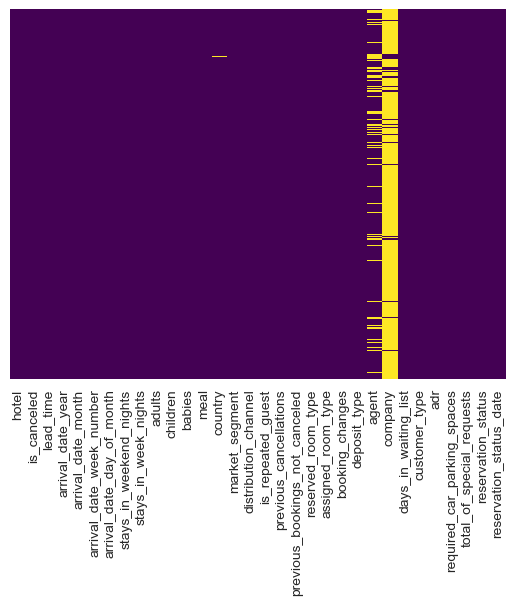

In [13]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

Visualising missing values using a heatmap.

Each highlighted region represents missing data.

This confirms that the main columns affected are:

- `country`
- `children`
- `agent`
- `company`

The heatmap also shows the approximate amount of missing information.

**Step 2 — Fix data types.**

Several columns are stored in incorrect formats.

Dates need to be converted into proper datetime objects so we can:

- Sort records
- Extract months and years
- Perform time-based analysis

In [14]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], format='mixed')

Converts `reservation_status_date` from string format into a proper datetime format.

This allows easier date manipulation and analysis.

In [15]:
arrival_date = (df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'].astype(str) + '-' + df['arrival_date_day_of_month'].astype(str))

df['arrival_date'] = pd.to_datetime(arrival_date, format='%Y-%B-%d')
df = df.drop(columns=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'])
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_week_number',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'arrival_date'],
      dtype='object')

Creates a new `arrival_date` column by combining:

- Arrival year
- Arrival month
- Arrival day

The original three columns are removed because they are now redundant.

This new `arrival_date` is used for all seasonality and monthly analysis because it represents the actual planned guest arrival date.

In [16]:
df = df.drop(df[df.children == 10].index)

In [17]:
df = df.drop(df[df.babies >= 9].index)

**Step 3 — Fix invalid `children` and `babies` values.**

Some records contain unrealistic values such as:

- 10 children
- Extremely high baby counts

These are treated as data entry errors and removed because the correct value cannot be reliably estimated.

In [18]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_week_number              0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82134
days_in_waiting_list                  0
customer_type                         0
adr                                   0


**Step 4 — Handle missing values.**

After fixing data types and removing invalid rows, we re-check missing values.

This helps identify exactly which columns still require treatment before continuing analysis.

In [19]:
df.drop(['company', 'agent'], axis = 1, inplace=True)

**Step 5 — Drop low-value columns.**

Two columns are removed:

- `company` → Around 94% missing values, making it unsuitable for reliable analysis.
- `agent` → Contains only anonymised IDs and provides limited business insight.

Removing these simplifies the dataset without affecting important analysis.

In [20]:
df.fillna({'children': 0}, inplace=True)
df.fillna({'country' : 'Unknown'}, inplace=True)

**Step 6 — Fill remaining missing values.**

Missing values are handled logically:

- `children` → Filled with 0 because missing usually indicates no children mentioned.
- `country` → Filled with `"Unknown"` to preserve records instead of deleting them.

This keeps maximum useful information while maintaining data quality.

In [21]:
df['children'] = df['children'].astype('int64')

In [22]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_week_number          0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status                0
reservation_status_date           0
arrival_date                

In [23]:
df = df[(df['adr'] < 5000) & (df['adr'] > 0)]

In [24]:
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

In [25]:
df = df[(df['stays_in_weekend_nights'] + df['stays_in_week_nights']) != 0]

**Step 7 — Remove invalid rows.**

Final sanity checks:

- Remove unrealistic ADR values (`adr < 0` or extremely high values)
- Remove bookings with zero guests
- Remove bookings with zero stay duration

These records do not represent valid hotel stays and could distort business insights.

## 3. Feature Engineering

After cleaning the dataset, new analytical features are created.

These derived columns help answer business questions related to:

- Customer behaviour
- Revenue generation
- Stay patterns
- Cancellation risk
- Seasonality

In [26]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

Creates `total_nights`.

Formula:

`total_nights = weekend nights + weekday nights`

This represents the complete duration of a guest's stay and is used for revenue and stay analysis.

In [27]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

Creates `total_guests`.

Formula:

`total_guests = adults + children + babies`

This represents the total number of people included in each booking.

In [28]:
df['revenue'] = df['adr'] * df['total_nights']

Creates `revenue`.

Formula:

`revenue = adr × total_nights`

Important:

This includes cancelled bookings too, because cancelled reservations still have an ADR value.

For actual earned revenue, only bookings where:

`is_canceled == 0`

should be considered.

In [29]:
df['room_matched'] = (df['reserved_room_type'] == df['assigned_room_type']).astype(int)

Creates `room_matched`.

This identifies whether guests received the same room type they originally reserved.

Values:

- 1 → Assigned room matches reserved room
- 0 → Guest was moved to another room type

Useful for studying upgrade and downgrade patterns.

In [30]:
bins = [-1, 0, 7, 30, 90, 180, float('inf')]
labels = ['Same day', 'Last minute', 'Short', 'Medium', 'Long', 'Very long']

# 4. Create the bucket column
df['lead_bucket'] = pd.cut(df['lead_time'], bins=bins, labels=labels)
print(df[df['is_canceled'] == 0]['lead_bucket'].value_counts())

lead_bucket
Medium         15253
Short          11938
Long           11753
Last minute    10682
Very long       6985
Same day        5133
Name: count, dtype: int64


Creates lead time categories.

The original `lead_time` values are grouped into meaningful ranges:

- Same day
- Short term
- Medium term
- Long term
- Very long term

This makes cancellation behaviour easier to interpret compared to raw day values.

In [31]:
# 3. Define month-to-season dictionary
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

# 4. Map the season
df['reservation_status_seasons'] = df['reservation_status_date'].dt.month.map(season_map)
print(df['reservation_status_seasons'].value_counts())

reservation_status_seasons
Summer    25054
Spring    23774
Autumn    18903
Winter    17851
Name: count, dtype: int64


Creates season categories based on arrival month.

Each booking is assigned to:

- Winter
- Spring
- Summer
- Autumn

This helps analyze seasonal booking patterns and revenue trends.

## 4. Customer Behaviour & Booking Patterns

This section answers:

**Who books hotels, how do they book, and what are their booking habits?**

Analysis includes:

- Hotel type distribution
- Repeat customer behaviour
- Lead time patterns
- Average stay duration
- Customer source markets

In [32]:
total_bookings = df[df['is_canceled'] == 0]
total = int(total_bookings['is_canceled'].count())
print(f'Total number of bookings : {total}')

Total number of bookings : 61744


#### KPI Metrics — Customer Behaviour

Total confirmed bookings across both hotels.

This represents the overall booking volume after removing cancelled reservations.

In [33]:
resort = total_bookings[total_bookings['hotel'] == 'Resort Hotel']
resort_bookings = int(resort['is_canceled'].count())
print(f'Total number of bookings Of Resort Hotel : {resort_bookings}')

Total number of bookings Of Resort Hotel : 25364


Confirmed bookings for:

**Resort Hotel**

Used to compare customer demand between hotel categories.

In [34]:
city_bookings = total - resort_bookings
print(f'Total number of bookings Of City Hotel : {city_bookings}')

Total number of bookings Of City Hotel : 36380


Confirmed bookings for:

**City Hotel**

Calculated separately to compare performance against Resort Hotel.

In [35]:
repeat_guests_percentage = round(float(df['is_repeated_guest'].mean() * 100), 2)
print(f'The Repeated Guests Percentage % is {repeat_guests_percentage}')

The Repeated Guests Percentage % is 3.41


Percentage of repeat guests among all bookings.

This acts as a customer loyalty indicator.

A low repeat guest percentage suggests an opportunity for loyalty programs and retention strategies.

In [36]:
average_lead = round(float(df[df['hotel'] == 'Resort Hotel']['lead_time'].mean()), 2)
print(f'The Average Lead Time of the Resort Hotel : {average_lead}')

The Average Lead Time of the Resort Hotel : 83.99


Average booking lead time for:

**Resort Hotel**

Shows how early customers typically plan their stays.

In [37]:
average_lead = round(float(df[df['hotel'] == 'City Hotel']['lead_time'].mean()), 2)
print(f'The Average Lead Time of the City Hotel : {average_lead}')

The Average Lead Time of the City Hotel : 78.64


Average booking lead time for:

**City Hotel**

Comparing this with Resort Hotel helps identify differences in booking behaviour.

In [38]:
avg_stay = df.groupby(['customer_type', 'hotel'])['total_nights'].mean()
avg_stay

customer_type    hotel       
Contract         City Hotel      3.174092
                 Resort Hotel    8.614502
Group            City Hotel      2.557252
                 Resort Hotel    3.092742
Transient        City Hotel      3.229889
                 Resort Hotel    4.258592
Transient-Party  City Hotel      2.838151
                 Resort Hotel    4.131422
Name: total_nights, dtype: float64

Average stay duration by:

- Customer type
- Hotel type

This helps understand whether different customer groups prefer shorter or longer stays and how this differs between hotels.

#### Visualisations — Customer Behaviour

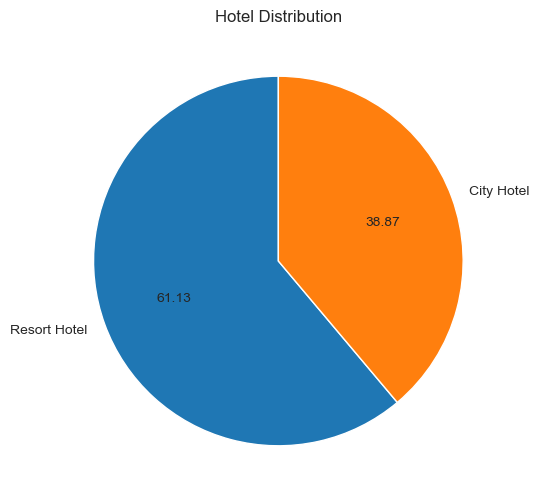

In [39]:
plt.figure(figsize=(12, 6))
plt.pie(df['hotel'].value_counts(), labels=['Resort Hotel', 'City Hotel'], autopct='%.2f', startangle=90)
plt.title('Hotel Distribution')
plt.savefig("../images/01_bookings_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Pie chart showing the overall distribution of bookings between:

- Resort Hotel
- City Hotel

This gives a quick view of customer preference between the two hotel types.

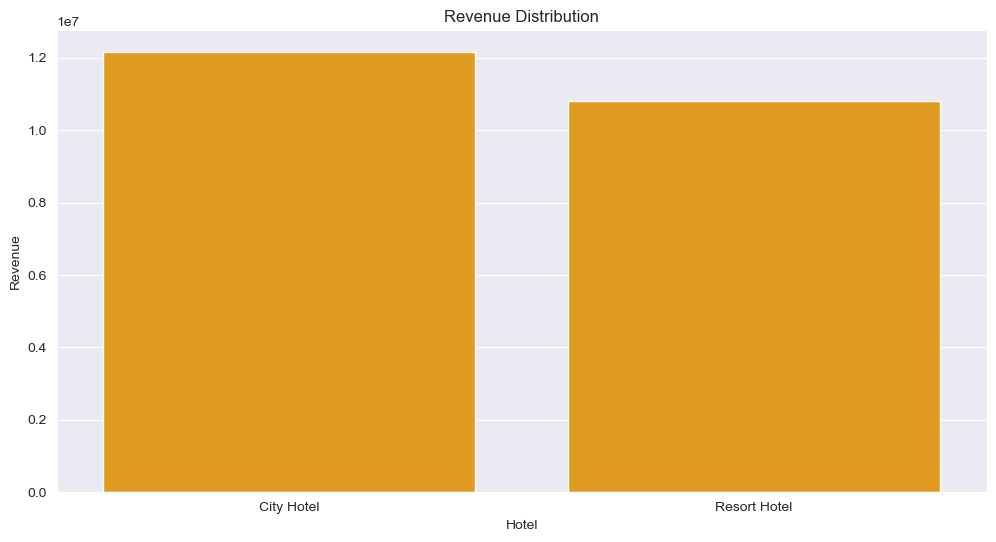

In [40]:
cancel_revenue = df[df['is_canceled'] == 0].groupby('hotel')['revenue'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=cancel_revenue.index, y=cancel_revenue.values, color='orange')
plt.title('Revenue Distribution')
plt.xlabel('Hotel')
plt.ylabel('Revenue')
plt.show()

Bar chart comparing confirmed revenue generated by each hotel type.

This helps identify which property contributes more towards actual revenue.

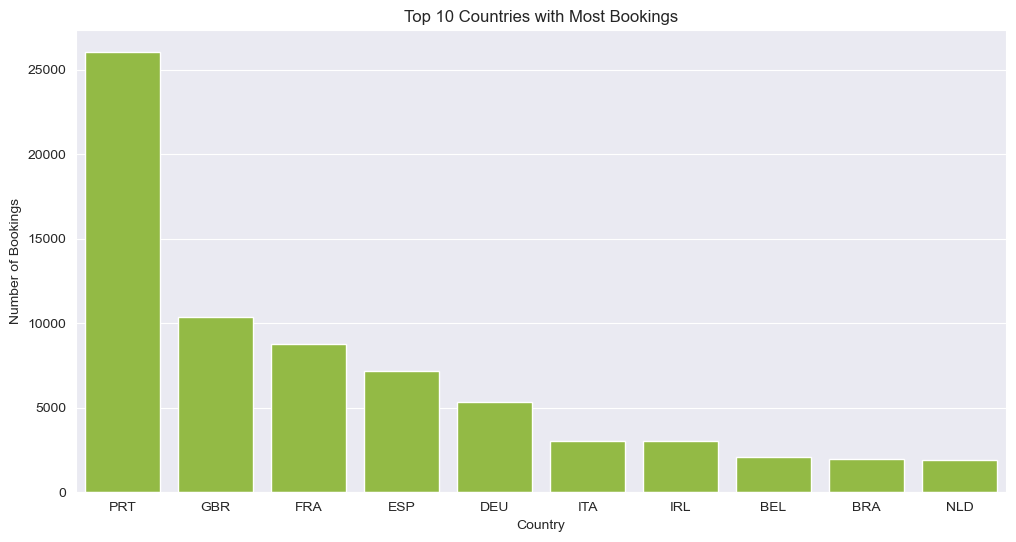

In [41]:
top_10_country = df['country'].value_counts()[:10]

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_country.index, y=top_10_country.values, color='yellowgreen')
plt.title('Top 10 Countries with Most Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.savefig("../images/02_top_10_countries.png", dpi=300, bbox_inches="tight")
plt.show()

Bar chart showing the top 10 countries based on booking volume.

This identifies the major customer source markets for the hotels.

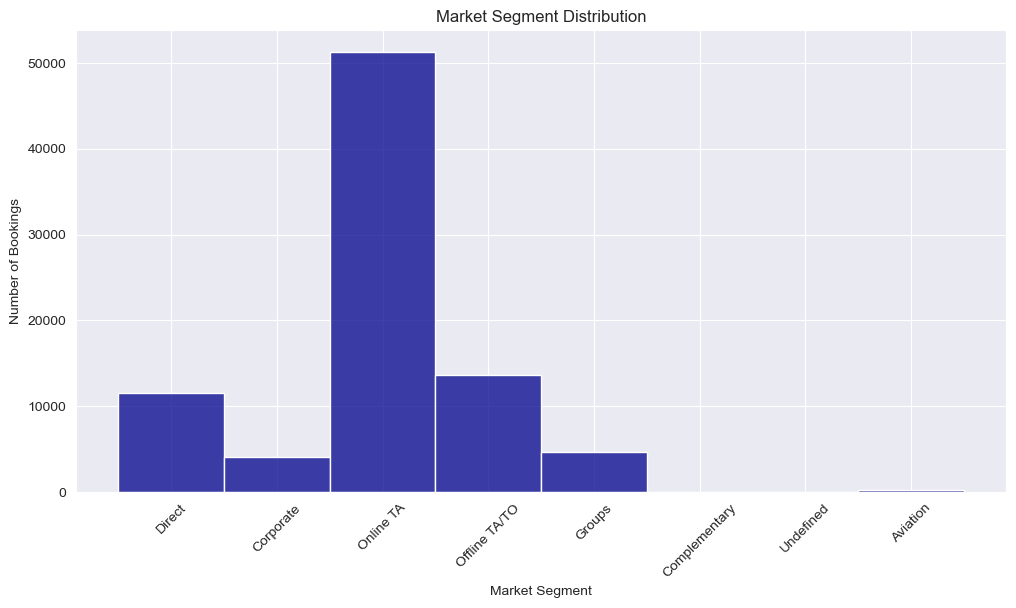

In [42]:
plt.figure(figsize=(12, 6))

# Seaborn automatically counts text categories when passed to histplot
sns.histplot(data=df, x='market_segment', color='darkblue')
plt.title('Market Segment Distribution')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45) # Rotates labels if they overlap
plt.savefig("../images/03_market_segment.png", dpi=300, bbox_inches="tight")
plt.show()

Distribution of bookings across different market segments:

Examples:

- Online Travel Agents
- Direct bookings
- Corporate bookings

This helps understand which channels generate the highest booking volume.

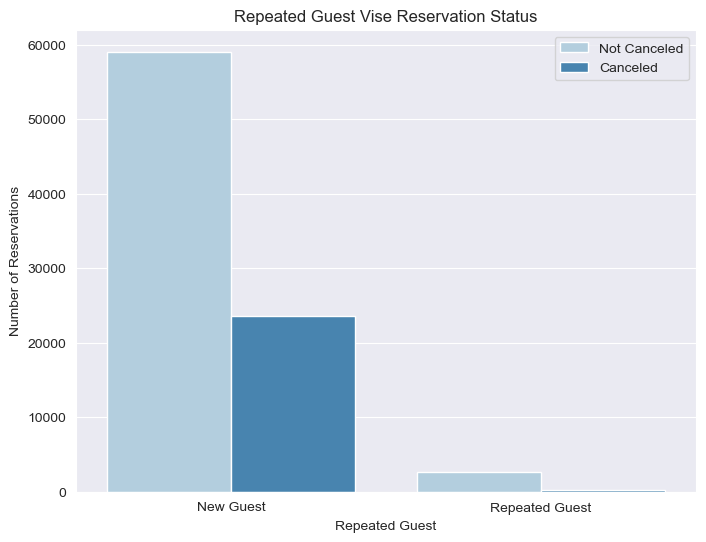

In [43]:
plt.figure(figsize=(8, 6))
ax1 = sns.countplot(x='is_repeated_guest', hue='is_canceled', data=df, palette= 'Blues')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['New Guest', 'Repeated Guest'])
legend_labels = ax1.get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', labels=legend_labels[0])
plt.title('Repeated Guest Vise Reservation Status')
plt.xlabel('Repeated Guest')
plt.ylabel('Number of Reservations')
plt.legend(['Not Canceled', 'Canceled'])
plt.savefig("../images/04_repeated_guest.png", dpi=300, bbox_inches="tight")
plt.show()

Grouped bar chart comparing cancellation behaviour between:

- New guests
- Repeat guests

This helps identify whether customer loyalty reduces cancellation risk.

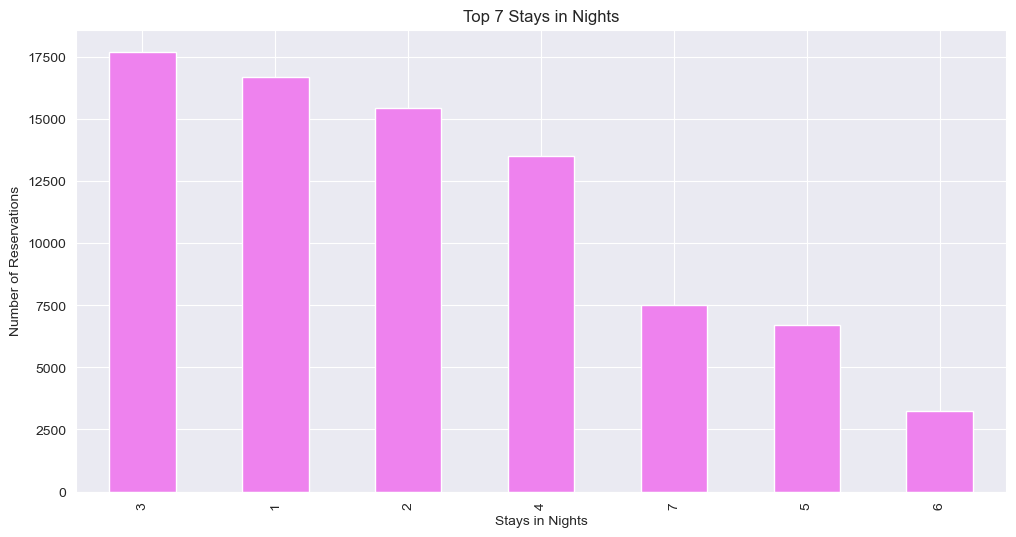

In [44]:
plt.figure(figsize=(12, 6))
df['total_nights'].value_counts()[:7].plot(kind='bar', color='violet')
plt.title('Top 7 Stays in Nights')
plt.xlabel('Stays in Nights')
plt.ylabel('Number of Reservations')
plt.show()

Bar chart showing the most common stay durations.

This highlights the number of nights most customers typically choose when booking hotels.

## 5. Cancellation Analysis

This section focuses on the main business problem:

**What factors increase or reduce cancellation probability?**

Analysis includes:

- Hotel type
- Booking month
- Country
- Lead time
- Deposit type
- Feature correlations

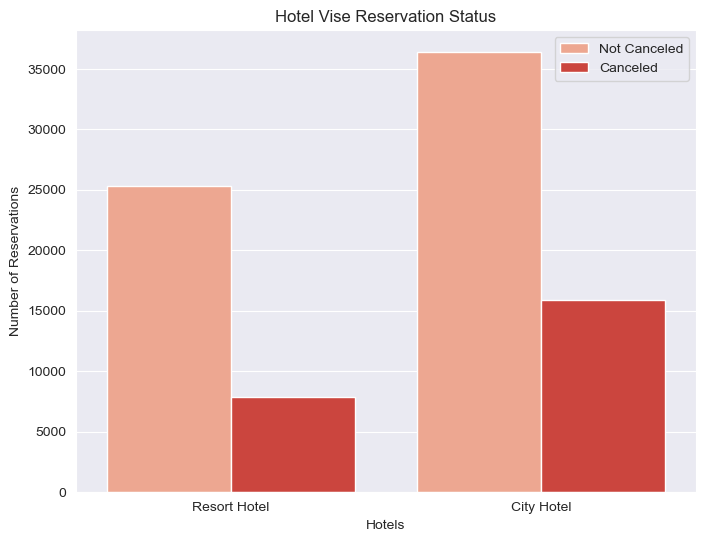

In [45]:
plt.figure(figsize=(8, 6))
ax1 = sns.countplot(x='hotel', hue='is_canceled', data=df, palette= 'Reds')
legend_labels = ax1.get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', labels=legend_labels[0])
plt.title('Hotel Vise Reservation Status')
plt.xlabel('Hotels')
plt.ylabel('Number of Reservations')
plt.legend(['Not Canceled', 'Canceled'])
plt.savefig("../images/05_hotel_vise_reservation_status.png", dpi=300, bbox_inches="tight")
plt.show()

Grouped bar chart showing cancellation outcomes by hotel type.

This provides the first comparison of cancellation behaviour between:

- Resort Hotel
- City Hotel

In [46]:
resort_hotel = df[df['hotel'] == 'Resort Hotel']
resort_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.762506
1    0.237494
Name: proportion, dtype: float64

Cancellation distribution specifically for Resort Hotel.

Shows the percentage of:

- Cancelled bookings
- Completed bookings

In [47]:
city_hotel = df[df['hotel'] == 'City Hotel']
city_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.695363
1    0.304637
Name: proportion, dtype: float64

Cancellation distribution specifically for City Hotel.

This allows direct comparison with Resort Hotel cancellation patterns.

In [48]:
resort_hotel = resort_hotel.groupby('reservation_status_date')[['adr']].mean()
city_hotel = city_hotel.groupby('reservation_status_date')[['adr']].mean()

Groups ADR values over time separately for both hotel types.

This prepares the dataset for analysing pricing trends.

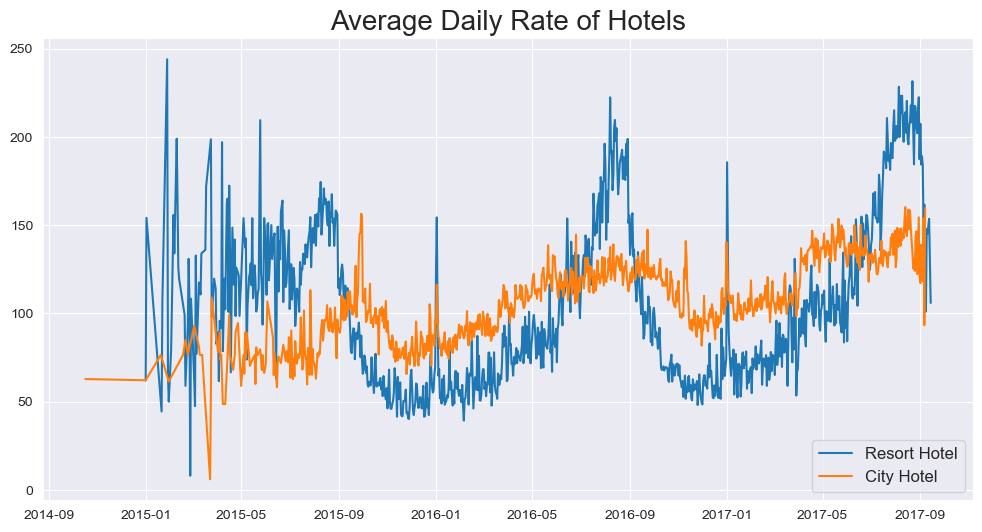

In [49]:
plt.figure(figsize=(12, 6))
plt.title('Average Daily Rate of Hotels', fontsize=20)
plt.plot(resort_hotel.index, resort_hotel['adr'], label = 'Resort Hotel')
plt.plot(city_hotel.index, city_hotel['adr'], label = 'City Hotel')
plt.legend(fontsize=12)
plt.show()

Line chart comparing average daily rate (ADR) trends between:

- Resort Hotel
- City Hotel

This reveals pricing changes and seasonal patterns over time.

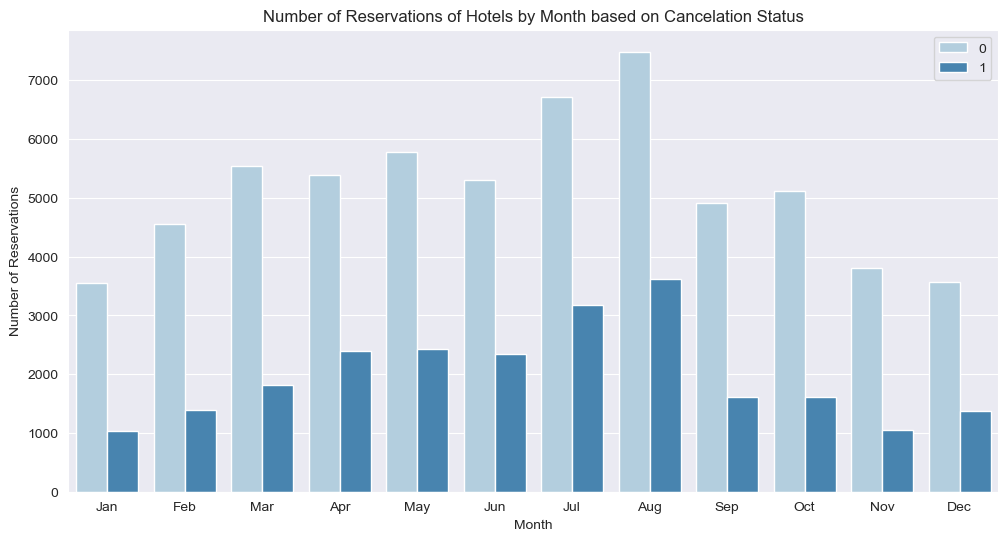

In [50]:
df['month'] = df['arrival_date'].dt.month

plt.figure(figsize=(12, 6))
ax1 = sns.countplot(x='month', hue='is_canceled', data=df, palette= 'Blues')
legend_labels = ax1.get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', labels=legend_labels[0])
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Month')
plt.ylabel('Number of Reservations')
plt.title('Number of Reservations of Hotels by Month based on Cancelation Status')
plt.legend(['Not Canceled', 'Canceled'])
plt.legend()
plt.show()

Creates the `month` feature from `arrival_date`.

This uses the guest's planned arrival month instead of reservation status date because:

- Arrival date represents actual demand timing
- Reservation status date represents booking updates

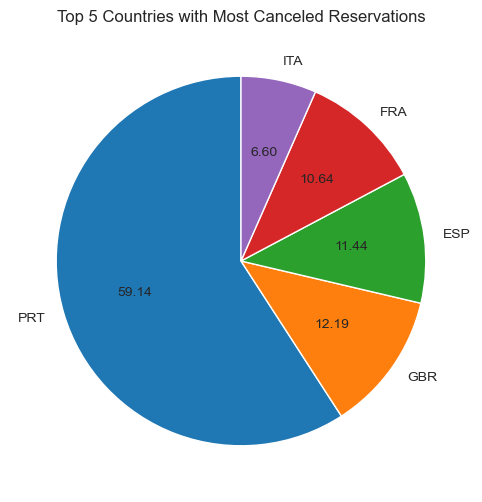

In [51]:
canceled_data = df[df['is_canceled'] == 1]
top_10_country = canceled_data['country'].value_counts()[:5]

plt.figure(figsize=(12, 6))
plt.pie(top_10_country, labels=top_10_country.index, autopct='%.2f', startangle=90)
plt.title('Top 5 Countries with Most Canceled Reservations')
plt.show()

Pie chart showing the top 5 countries contributing to cancelled bookings.

This identifies major markets where cancellation losses are concentrated.

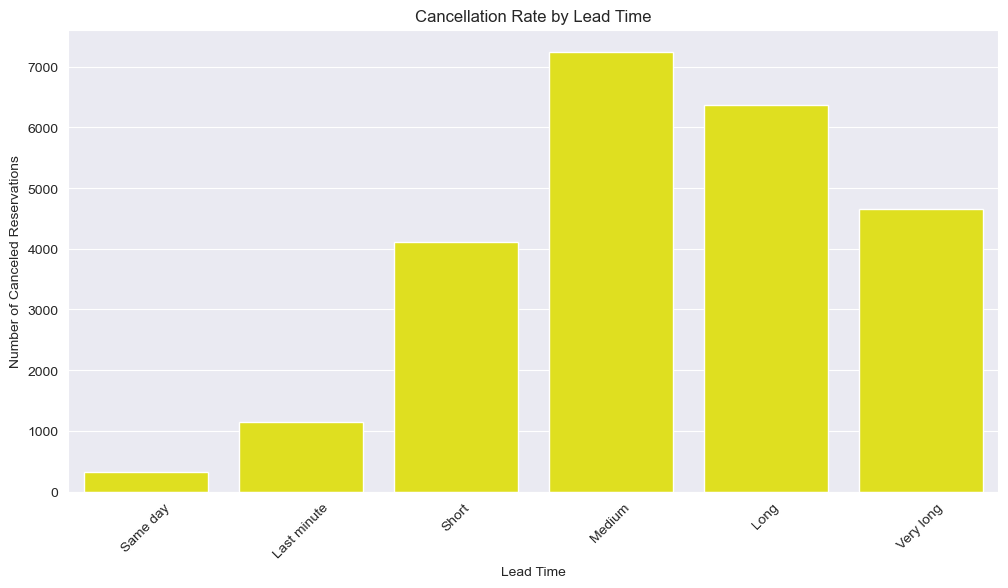

In [52]:
lead_cancel = df[df['is_canceled'] == 1].groupby('lead_bucket', observed=False)['is_canceled'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=lead_cancel,x='lead_bucket', y='is_canceled',color='yellow')
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Number of Canceled Reservations')
plt.xticks(rotation=45)
plt.savefig("../images/06_lead_time_cancellation.png", dpi=300, bbox_inches="tight")
plt.show()

Bar chart showing cancellation counts across lead time categories.

This helps understand whether customers booking earlier are more likely to cancel.

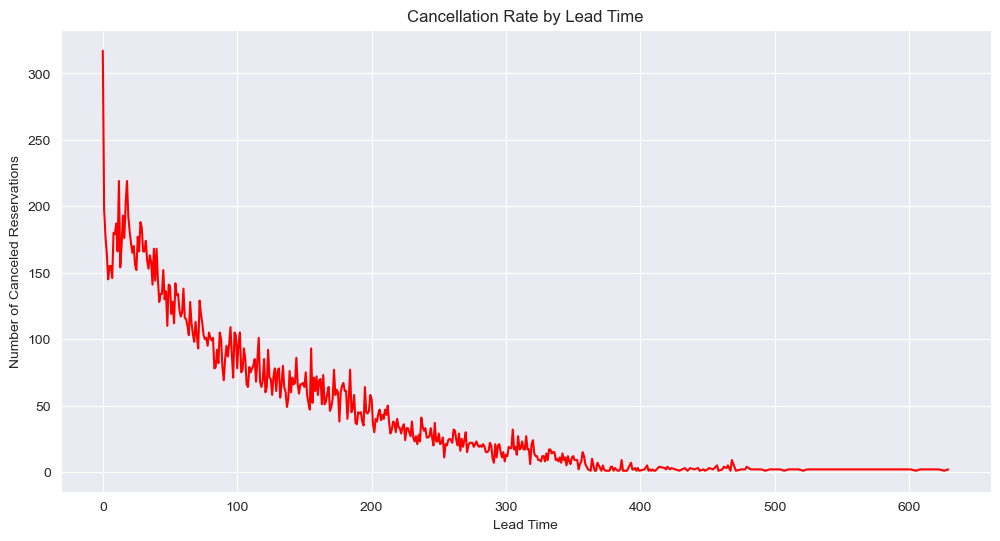

In [53]:
lead_time_cancel = df[df['is_canceled'] == 1].groupby('lead_time', observed=False)['is_canceled'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=lead_time_cancel, x='lead_time', y='is_canceled', color='red')
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Number of Canceled Reservations')
plt.savefig("../images/07_lead_time_cancellation_line.png", dpi=300, bbox_inches="tight")
plt.show()

Line chart showing cancellation behaviour against raw lead time values.

Unlike grouped categories, this provides a detailed view of where cancellation risk increases.

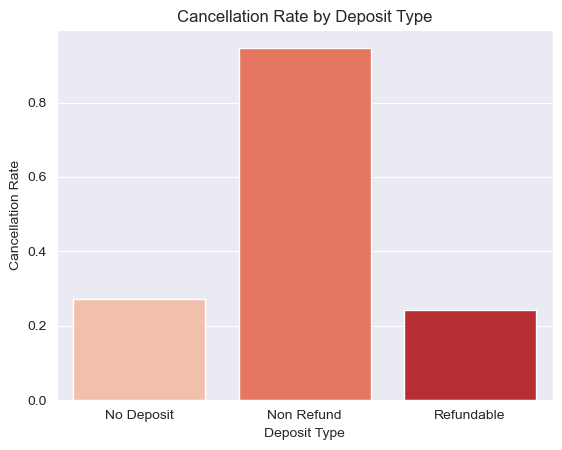

In [54]:
cancel_by_deposit = df.groupby('deposit_type')['is_canceled'].mean().reset_index()
sns.barplot(data=cancel_by_deposit, x='deposit_type', y='is_canceled',hue='deposit_type', palette='Reds')
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')
plt.show()

Bar chart showing cancellation rate by deposit type.

This is an important business insight because deposit policies can influence customer cancellation behaviour.

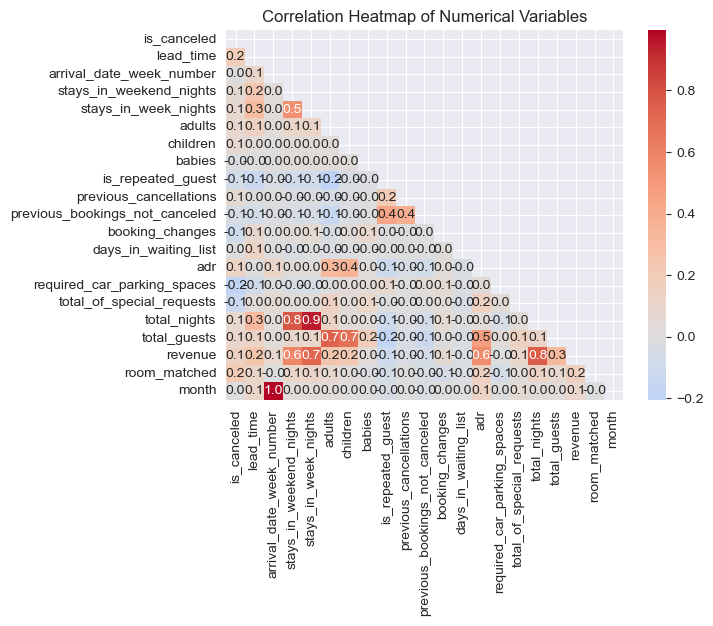

In [55]:
import numpy as np

num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.1f', mask=mask, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.savefig('../images/08_correlation_heatmap.png', dpi=300, bbox_inches='tight')

Correlation heatmap of numerical variables.

Purpose:

Identify which numerical factors have relationships with:

`is_canceled`

Important expected relationships:

- Lead time
- Previous cancellations
- Special requests

## 6. Revenue & Pricing Analysis

This section analyses:

- Revenue contributors
- Room type performance
- Revenue loss caused by cancellations
- Relationship between stay duration and revenue

Only completed bookings are considered for actual revenue analysis.

In [56]:
avg_revenue = df[df['is_canceled'] == 0].groupby('hotel')['revenue'].sum()
print(f'Average Revenue : {avg_revenue}')

Average Revenue : hotel
City Hotel      12150123.83
Resort Hotel    10817034.22
Name: revenue, dtype: float64


Calculates total confirmed revenue separately for:

- Resort Hotel
- City Hotel

This provides the main revenue comparison between properties.

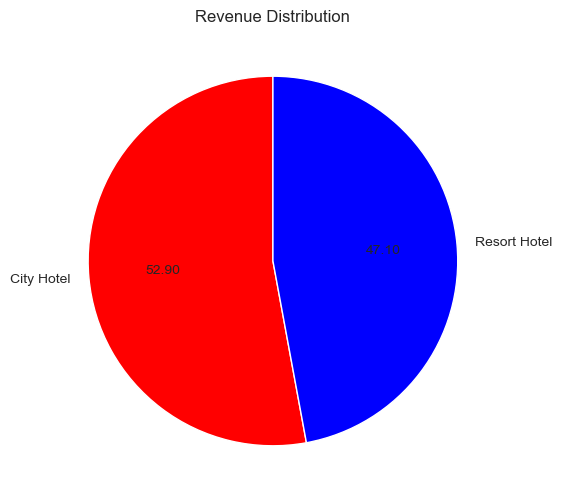

In [57]:
hotel_revenue = df[df['is_canceled'] != 1].groupby('hotel')['revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.pie(hotel_revenue['revenue'], labels=hotel_revenue['hotel'], autopct='%.2f', startangle=90, colors = ['red', 'blue'])
plt.title('Revenue Distribution')
plt.savefig("../images/09_hotel_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

Pie chart showing revenue contribution percentage from each hotel type.

This provides a simple visual comparison of revenue share.

Filters only non-cancelled bookings.

This ensures revenue analysis represents actual earned revenue instead of potential revenue.

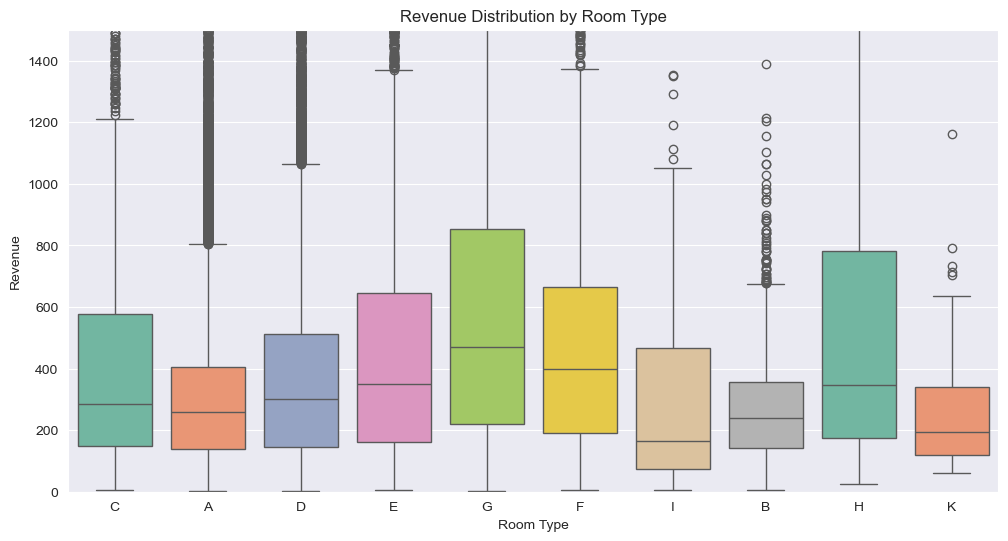

In [58]:
revenue_by_room = df[df['is_canceled'] != 1]

plt.figure(figsize=(12, 6))
sns.boxplot(x='assigned_room_type', y='revenue', data=revenue_by_room,hue='assigned_room_type', palette='Set2')
plt.title('Revenue Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Revenue')
plt.ylim(0, 1500)
plt.savefig("../images/10_revenue_by_room.png", dpi=300, bbox_inches="tight")
plt.show()

Box plot showing revenue distribution by assigned room type.

This helps identify:

- High-performing room categories
- Revenue variation
- Outliers

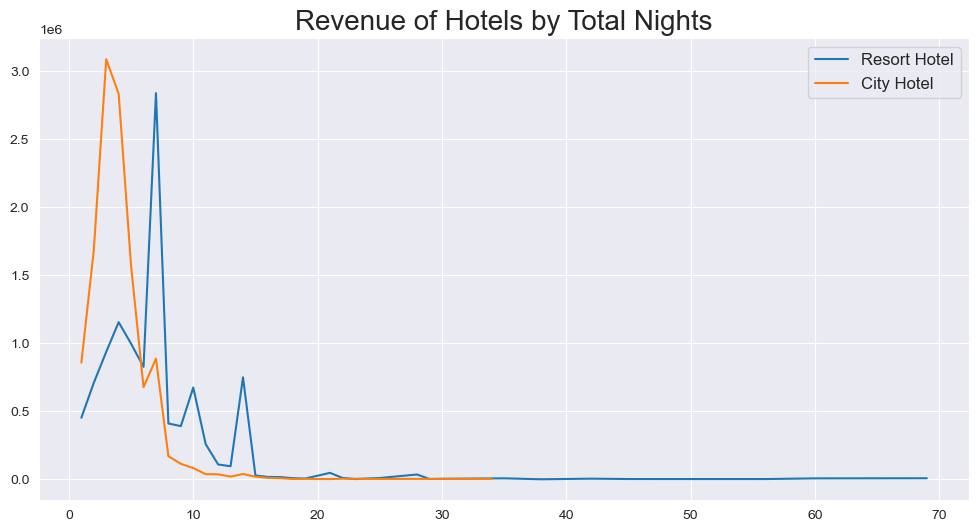

In [59]:
resort_revenue = df[(df['is_canceled'] != 1) & (df['hotel'] == 'Resort Hotel')].groupby('total_nights')['revenue'].sum().reset_index()
city_revenue = df[(df['is_canceled'] != 1) & (df['hotel'] == 'City Hotel')].groupby('total_nights')['revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.title('Revenue of Hotels by Total Nights', fontsize=20)
plt.plot(resort_revenue['total_nights'], resort_revenue['revenue'], label = 'Resort Hotel')
plt.plot(city_revenue['total_nights'], city_revenue['revenue'], label = 'City Hotel')
plt.legend(fontsize=12)
plt.savefig("../images/11_revenue_by_total_nights.png", dpi=300, bbox_inches="tight")
plt.show()

Line chart comparing revenue with length of stay.

This helps understand whether longer stays consistently generate higher revenue.

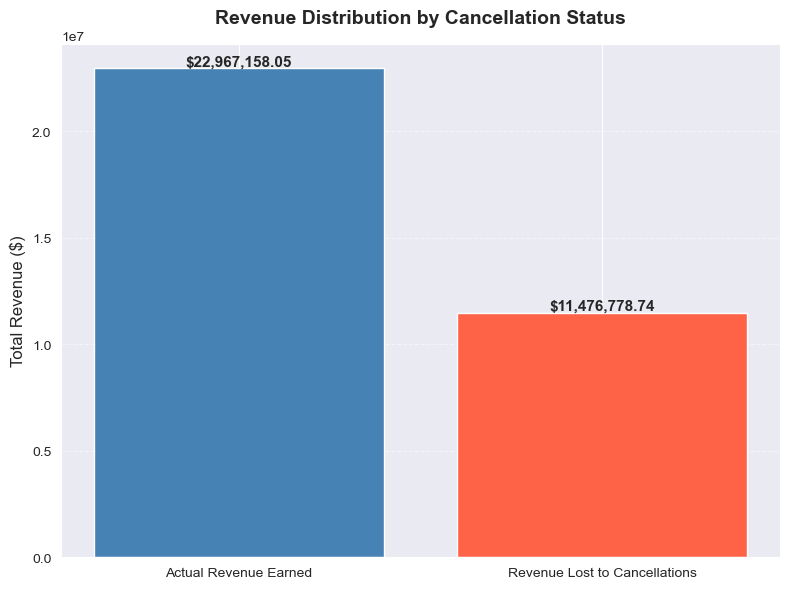

In [60]:
import matplotlib.pyplot as plt

actual_rev  = df[df['is_canceled'] == 0]['revenue'].sum()
rev_lost    = df[df['is_canceled'] == 1]['revenue'].sum()

# Your defined variables
labels = ['Actual Revenue Earned', 'Revenue Lost to Cancellations']
values = [actual_rev, rev_lost]
colors = ['steelblue', 'tomato']

# Create the plot
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=colors)

# Add value labels on top of each bar for clarity
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'${height:,.2f}', # Formats the number as currency (e.g., $10,250.00)
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Titles and Labels
plt.title('Revenue Distribution by Cancellation Status', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Adds a light grid for readability

# Adjust layout and show
plt.tight_layout()
plt.savefig("../images/12_revenue_by_cancellation_status.png", dpi=300, bbox_inches="tight")
plt.show()

Compares:

- Actual revenue earned from completed bookings
- Potential revenue lost from cancelled bookings

This measures the financial impact of cancellations.

([<matplotlib.axis.XTick at 0x17291371950>,
 [Text(1, 0, 'Jan'),
  Text(2, 0, 'Feb'),
  Text(3, 0, 'Mar'),
  Text(4, 0, 'Apr'),
  Text(5, 0, 'May'),
  Text(6, 0, 'Jun'),
  Text(7, 0, 'Jul'),
  Text(8, 0, 'Aug'),
  Text(9, 0, 'Sep'),
  Text(10, 0, 'Oct'),
  Text(11, 0, 'Nov'),
  Text(12, 0, 'Dec')])

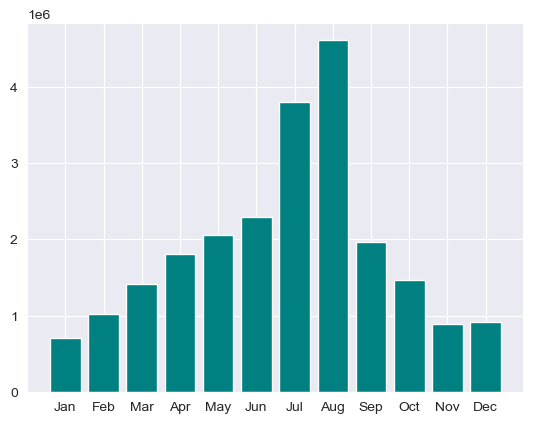

In [61]:
net_monthly = df[df['is_canceled']==0].groupby('month')['revenue'].sum()
plt.bar(net_monthly.index, net_monthly.values, color='teal')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

Calculates monthly net revenue from completed bookings.

This shows the actual monthly income generated by the hotels.

## 7. Seasonality & Peak Period Analysis

This section answers:

**When is demand highest and how do cancellations behave during peak periods?**

All analysis is based on guest arrival dates.

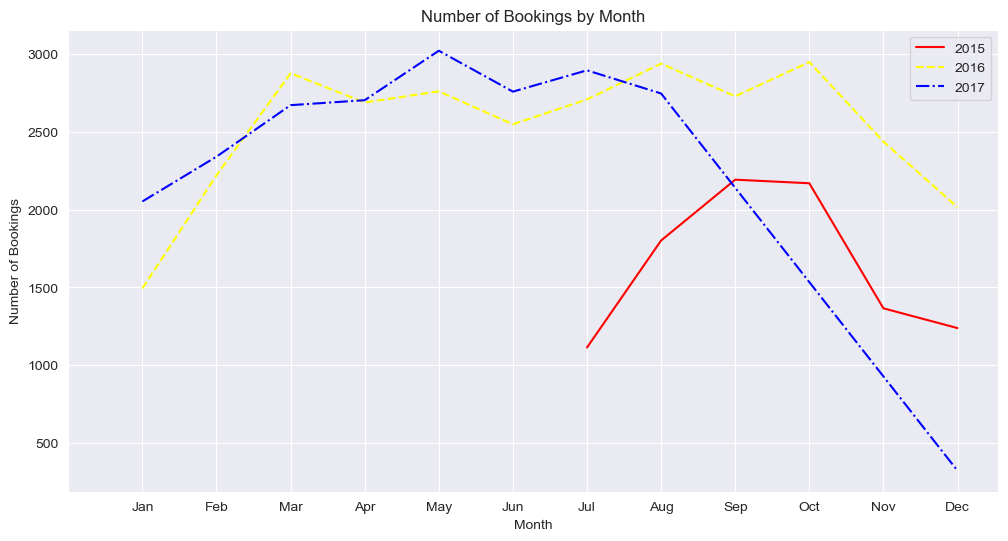

In [62]:
month_booking_15 = df[(df['is_canceled'] != 1) & (df['reservation_status_date'].dt.year == 2015)].groupby('month')['reservation_status'].count().reset_index()
month_booking_16 = df[(df['is_canceled'] != 1) & (df['reservation_status_date'].dt.year == 2016)].groupby('month')['reservation_status'].count().reset_index()
month_booking_17 = df[(df['is_canceled'] != 1) & (df['reservation_status_date'].dt.year == 2017)].groupby('month')['reservation_status'].count().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(month_booking_15['month'], month_booking_15['reservation_status'], color='red')
plt.plot(month_booking_16['month'], month_booking_16['reservation_status'], color='yellow', linestyle='--')
plt.plot(month_booking_17['month'], month_booking_17['reservation_status'], color='blue', linestyle='-.')
plt.title('Number of Bookings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(range(0, 13), ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(['2015', '2016', '2017'])
plt.savefig("../images/13_month_booking_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Multi-year monthly booking trend analysis.

Compares booking volume across:

- 2015
- 2016
- 2017

This highlights seasonal demand patterns.

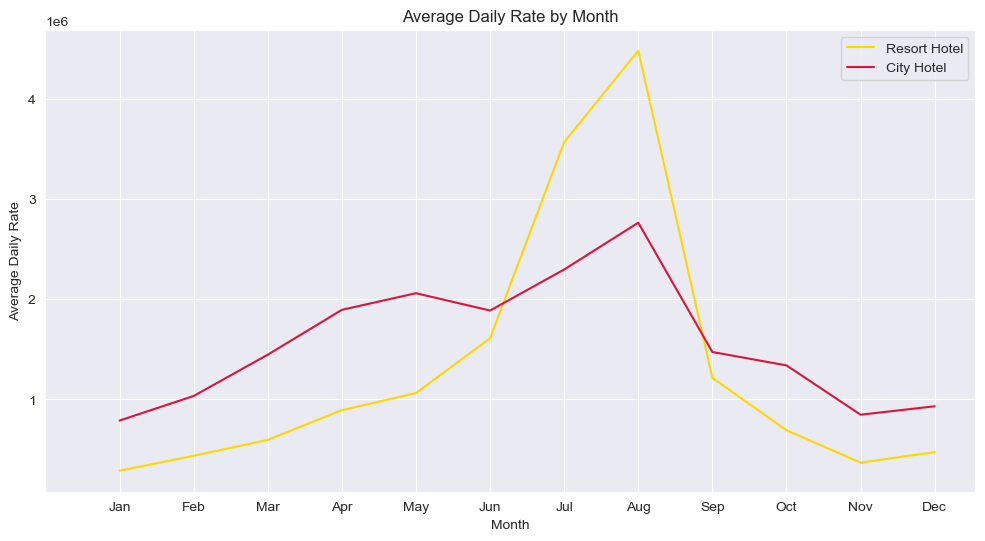

In [63]:
resort_month_adr = df[df['hotel'] == 'Resort Hotel'].groupby('month')['revenue'].sum().reset_index()
city_month_adr = df[df['hotel'] == 'City Hotel'].groupby('month')['revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(resort_month_adr['month'], resort_month_adr['revenue'], color='gold')
plt.plot(city_month_adr['month'], city_month_adr['revenue'], color='crimson')
plt.title('Average Daily Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate')
plt.xticks(range(0, 13), ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(['Resort Hotel', 'City Hotel'])
plt.show()

Line chart comparing monthly revenue trends between:

- Resort Hotel
- City Hotel

Shows whether both properties experience similar seasonal peaks.

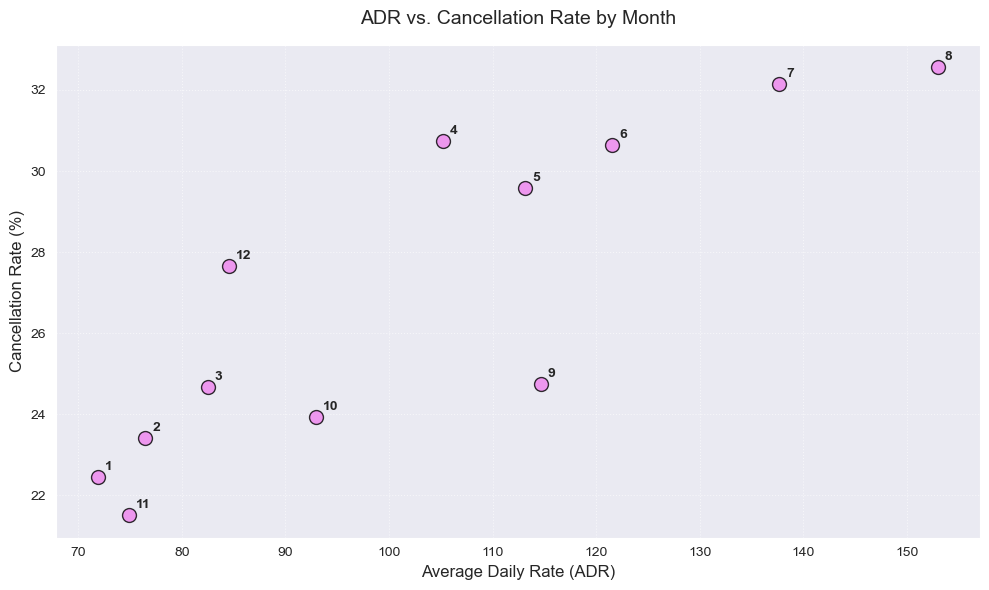

In [64]:
monthly_data = df.groupby('month').agg(
    avg_adr=('adr', 'mean'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()

# 4. Convert cancellation rate to a percentage
monthly_data['cancel_rate'] *= 100

plt.figure(figsize=(10, 6))

# Create the scatter plot
plt.scatter(
    monthly_data['avg_adr'],
    monthly_data['cancel_rate'],
    color='violet',
    s=100,            # Marker size
    edgecolor='black',
    alpha=0.8
)

# Label each scatter point with its month number/name
for i, row in monthly_data.iterrows():
    plt.annotate(
        text=int(row['month']), # Swap with month name if using strings
        xy=(row['avg_adr'], row['cancel_rate']),
        xytext=(5, 5),                 # Offset text slightly to the top-right
        textcoords='offset points',
        fontsize=10,
        weight='bold'
    )

# Chart styling
plt.title('ADR vs. Cancellation Rate by Month', fontsize=14, pad=15)
plt.xlabel('Average Daily Rate (ADR)', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Scatter plot comparing:

- Average ADR
- Monthly cancellation rate

This identifies whether higher-priced periods also experience higher cancellation risk.

## 8. Guest Profile & Loyalty

This section studies:

- Repeat customer behaviour
- Booking timing
- Pricing patterns

The goal is to understand customer loyalty and retention opportunities.

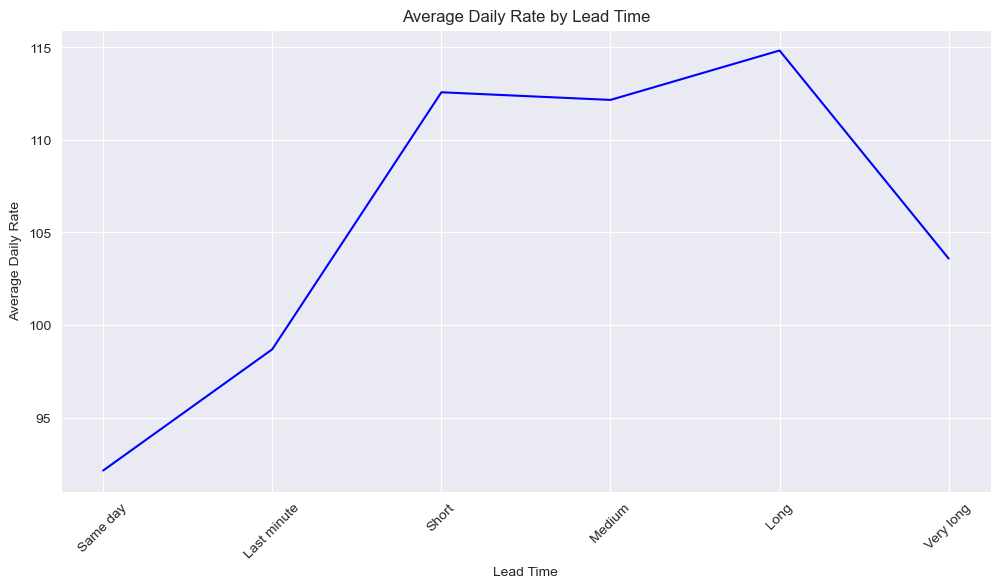

In [65]:
adr_lead = df.groupby('lead_bucket', observed=False)['adr'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(adr_lead['lead_bucket'], adr_lead['adr'], color='blue')
plt.title('Average Daily Rate by Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Average Daily Rate')
plt.xticks(rotation=45)
plt.show()

Line chart showing ADR variation across lead time categories.

This explains whether early bookers and last-minute customers pay different prices.

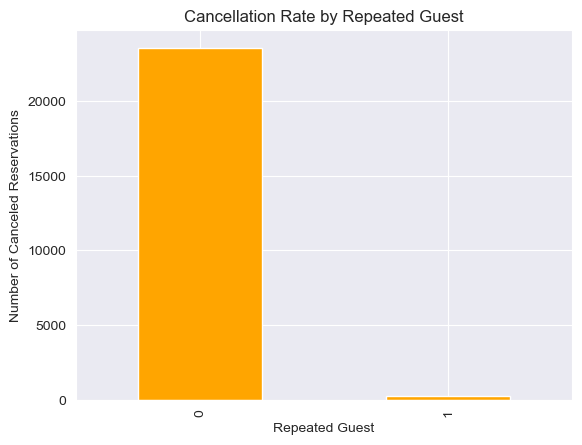

In [66]:
df[df['is_canceled'] == 1]['is_repeated_guest'].value_counts().plot(kind='bar', color='orange')
plt.xlabel('Repeated Guest')
plt.ylabel('Number of Canceled Reservations')
plt.title('Cancellation Rate by Repeated Guest')
plt.savefig("../images/14_repeated_guest_cancellation.png", dpi=300, bbox_inches="tight")
plt.show()

Bar chart comparing cancellation counts between:

- Repeat guests
- New guests

This highlights the impact of customer loyalty on cancellation behaviour.

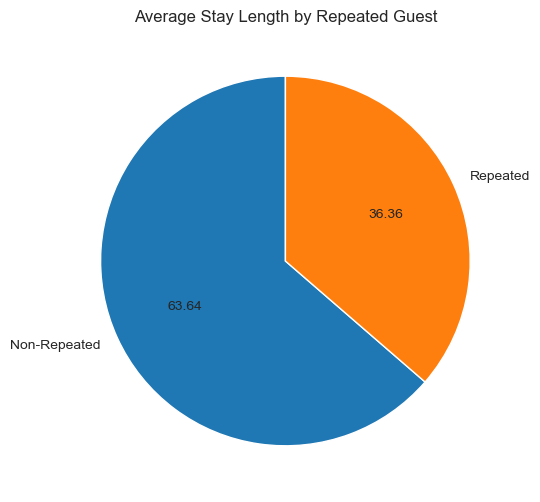

In [67]:
guest_nights = df.groupby('is_repeated_guest')['total_nights'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.pie(guest_nights['total_nights'], labels=['Non-Repeated', 'Repeated'], autopct='%.2f', startangle=90)
plt.title('Average Stay Length by Repeated Guest')
plt.savefig("../images/15_guest_stay_length.png", dpi=300, bbox_inches="tight")
plt.show()

Pie chart comparing average stay duration between:

- Repeat guests
- Non-repeat guests

This helps understand whether loyal customers contribute longer stays.

## 9. Key Findings Summary

- **Data Quality:** 26.8% of raw records were duplicates and removed. Missing values in important columns were handled carefully.

- **Cancellations:** City Hotel experiences higher cancellation rates. Lead time and previous cancellation history are important cancellation indicators.

- **Deposit Policy:** Deposit type has a strong relationship with cancellations and should be reviewed for better revenue protection.

- **Revenue:** Cancelled bookings create significant revenue loss, especially during high-demand periods.

- **Seasonality:** Peak seasons increase revenue opportunities but may also increase cancellation risk.

- **Customer Loyalty:** Repeat guests show lower cancellation behaviour, highlighting the value of loyalty programs.

**Future Improvement:**

A machine learning model such as Logistic Regression can be developed to predict cancellation probability and identify the strongest cancellation drivers.